# Arctic Grid Spectral Analysis Adaptation

This notebook adapts the spectral analysis functions to work with regular x/y Cartesian grids used in Arctic projections, replacing geographic lon/lat coordinates with Cartesian coordinates.

In [1]:
import numpy as np
import xarray as xr
import scipy.signal
from skimage.draw import line
import matplotlib.pyplot as plt
import logging

logger = logging.getLogger()
logger.setLevel(logging.INFO)

In [3]:
# Load Arctic Sea Ice Concentration data for spectral analysis
import glob
import os

print("="*80)
print("LOADING ARCTIC SEA ICE CONCENTRATION DATA FOR SPECTRAL ANALYSIS")
print("="*80)

# Define paths
netcdf_tests_dir = '/data/users/maxb/NetCDF_tests'
cimr_model_file = '/data/users/maxb/CROSCIM_dataset/out_CIMR/CIMR5km_2022-02-15.nc'
target_date = '2022-02-15T00:00:00.000000000'

# Find all NetCDF files
test_files = sorted(glob.glob(os.path.join(netcdf_tests_dir, '*.nc')))
print(f"\nFound {len(test_files)} prediction files in {netcdf_tests_dir}")

# Dictionary to store all datasets
arctic_data = {
    'reference': None,
    'model': None,
    'predictions': {},
    'grid_info': {}
}

# Step 1: Identify files and their resolutions
print("\n" + "="*80)
print("STEP 1: IDENTIFYING FILES AND RESOLUTIONS")
print("="*80)

file_metadata = []
for fpath in test_files:
    ds = xr.open_dataset(fpath)
    
    # Get grid info
    xc = ds.xc.values if 'xc' in ds.coords else ds.x.values
    yc = ds.yc.values if 'yc' in ds.coords else ds.y.values
    
    # Calculate resolution
    dx = np.abs(np.mean(np.diff(xc)))
    dy = np.abs(np.mean(np.diff(yc)))
    
    # Convert to km if in meters
    if dx > 1000:
        dx /= 1000.0
        dy /= 1000.0
    
    # Check which variables are present
    has_tgt_sic = 'tgt_sic' in ds.variables
    has_pred_sic = 'pred_sic' in ds.variables
    
    file_metadata.append({
        'path': fpath,
        'filename': os.path.basename(fpath),
        'resolution_km': dx,
        'nx': len(xc),
        'ny': len(yc),
        'xc': xc,
        'yc': yc,
        'dx': dx,
        'dy': dy,
        'has_tgt_sic': has_tgt_sic,
        'has_pred_sic': has_pred_sic
    })
    
    print(f"\n{os.path.basename(fpath)}:")
    print(f"  Resolution: {dx:.1f} km")
    print(f"  Grid size: {len(xc)} x {len(yc)}")
    print(f"  Has tgt_sic: {has_tgt_sic}")
    print(f"  Has pred_sic: {has_pred_sic}")
    
    ds.close()

# Sort by resolution (coarsest first for reference)
file_metadata.sort(key=lambda x: x['resolution_km'], reverse=True)

# Step 2: Load reference (coarsest resolution with tgt_sic)
print("\n" + "="*80)
print("STEP 2: LOADING REFERENCE DATA")
print("="*80)

ref_meta = None
for meta in file_metadata:
    if meta['has_tgt_sic']:
        ref_meta = meta
        break

if ref_meta is None:
    raise ValueError("No file with 'tgt_sic' variable found!")

print(f"Reference file: {ref_meta['filename']} ({ref_meta['resolution_km']:.1f} km)")

ds_ref = xr.open_dataset(ref_meta['path'])
if 'time' in ds_ref.dims:
    ds_ref_date = ds_ref.sel(time=target_date)
else:
    ds_ref_date = ds_ref

reference_data = ds_ref_date['tgt_sic'].values.squeeze()

# Handle 2D vs 3D data
if reference_data.ndim == 3:
    reference_data = reference_data[0]  # Take first time step if 3D

arctic_data['reference'] = reference_data
arctic_data['grid_info']['reference'] = {
    'xc': ref_meta['xc'],
    'yc': ref_meta['yc'],
    'dx': ref_meta['dx'],
    'dy': ref_meta['dy'],
    'resolution_km': ref_meta['resolution_km']
}

print(f"✓ Reference shape: {reference_data.shape}")
print(f"  Range: [{np.nanmin(reference_data):.4f}, {np.nanmax(reference_data):.4f}]")
print(f"  NaN%: {100 * np.isnan(reference_data).sum() / reference_data.size:.2f}%")

ds_ref.close()

# Step 3: Load model (CIMR)
print("\n" + "="*80)
print("STEP 3: LOADING MODEL DATA (CIMR)")
print("="*80)

if os.path.exists(cimr_model_file):
    print(f"Model file: {os.path.basename(cimr_model_file)}")
    
    ds_model = xr.open_dataset(cimr_model_file)
    print(ds_model)
    
    # Check for required variables
    if 'SIC' in ds_model.variables and 'SICnoise' in ds_model.variables:
        # Compute model prediction: SIC - SIcnoise
        model_data = (ds_model['SIC'] - ds_model['SICnoise']).values.squeeze()
        
        # Handle 3D data
        if model_data.ndim == 3:
            model_data = model_data[0]
        
        # Get grid coordinates
        xc_model = ds_model.xc.values if 'xc' in ds_model.coords else ds_model.x.values
        yc_model = ds_model.yc.values if 'yc' in ds_model.coords else ds_model.y.values
        
        dx_model = np.abs(np.mean(np.diff(xc_model)))
        dy_model = np.abs(np.mean(np.diff(yc_model)))
        
        if dx_model > 1000:
            dx_model /= 1000.0
            dy_model /= 1000.0
        
        arctic_data['model'] = model_data
        arctic_data['grid_info']['model'] = {
            'xc': xc_model,
            'yc': yc_model,
            'dx': dx_model,
            'dy': dy_model,
            'formula': 'SIC - SICnoise'
        }
        
        print(f"  Model shape: {model_data.shape}")
        print(f"  Resolution: {dx_model:.1f} km")
        print(f"  Range: [{np.nanmin(model_data):.4f}, {np.nanmax(model_data):.4f}]")
        print(f"  NaN%: {100 * np.isnan(model_data).sum() / model_data.size:.2f}%")
    else:
        print("ERROR: Required variables 'SIC' or 'SIcnoise' not found")
        arctic_data['model'] = None
    
    ds_model.close()
else:
    print(f"WARNING: Model file not found: {cimr_model_file}")
    arctic_data['model'] = None

# Step 4: Load predictions
print("\n" + "="*80)
print("STEP 4: LOADING PREDICTION DATA")
print("="*80)

pred_count = 0
for meta in file_metadata:
    if not meta['has_pred_sic']:
        continue
    
    pred_count += 1
    pred_name = f'pred{pred_count}'
    
    print(f"\n{pred_name}: {meta['filename']}")
    
    ds_pred = xr.open_dataset(meta['path'])
    
    if 'time' in ds_pred.dims:
        if target_date in ds_pred.time.astype(str).values:
            ds_pred_date = ds_pred.sel(time=target_date)
        else:
            print(f"  WARNING: Date {target_date} not found, using first timestep")
            ds_pred_date = ds_pred.isel(time=0)
    else:
        ds_pred_date = ds_pred
    
    pred_data = ds_pred_date['pred_sic'].values.squeeze()
    
    # Handle 3D data
    if pred_data.ndim == 3:
        pred_data = pred_data[0]
    
    arctic_data['predictions'][pred_name] = pred_data
    arctic_data['grid_info'][pred_name] = {
        'xc': meta['xc'],
        'yc': meta['yc'],
        'dx': meta['dx'],
        'dy': meta['dy'],
        'resolution_km': meta['resolution_km']
    }
    
    print(f"  ✓ Shape: {pred_data.shape}")
    print(f"    Resolution: {meta['resolution_km']:.1f} km")
    print(f"    Range: [{np.nanmin(pred_data):.4f}, {np.nanmax(pred_data):.4f}]")
    print(f"    NaN%: {100 * np.isnan(pred_data).sum() / pred_data.size:.2f}%")
    
    ds_pred.close()

# Summary
print("\n" + "="*80)
print("DATA LOADING SUMMARY")
print("="*80)

print(f"\n✓ Reference: {arctic_data['reference'].shape if arctic_data['reference'] is not None else 'NOT LOADED'}")
if arctic_data['reference'] is not None:
    print(f"  Resolution: {arctic_data['grid_info']['reference']['resolution_km']:.1f} km")

print(f"\n✓ Model: {arctic_data['model'].shape if arctic_data['model'] is not None else 'NOT LOADED'}")
if arctic_data['model'] is not None and 'model' in arctic_data['grid_info']:
    print(f"  Resolution: {arctic_data['grid_info']['model']['dx']:.1f} km")

print(f"\n✓ Predictions: {len(arctic_data['predictions'])} datasets loaded")
for pred_name in sorted(arctic_data['predictions'].keys()):
    shape = arctic_data['predictions'][pred_name].shape
    res = arctic_data['grid_info'][pred_name]['resolution_km']
    print(f"  {pred_name}: {shape} ({res:.1f} km)")

print("\n" + "="*80)
print("✓ ALL DATA READY FOR SPECTRAL ANALYSIS")
print("="*80)

LOADING ARCTIC SEA ICE CONCENTRATION DATA FOR SPECTRAL ANALYSIS

Found 2 prediction files in /data/users/maxb/NetCDF_tests

STEP 1: IDENTIFYING FILES AND RESOLUTIONS

test_data_20220201_20220215_patch_x50.nc:
  Resolution: 25.0 km
  Grid size: 304 x 294
  Has tgt_sic: True
  Has pred_sic: True

test_data_20220206_20220215_patch_x10.nc:
  Resolution: 5.0 km
  Grid size: 1520 x 1474
  Has tgt_sic: True
  Has pred_sic: True

STEP 2: LOADING REFERENCE DATA
Reference file: test_data_20220201_20220215_patch_x50.nc (25.0 km)
✓ Reference shape: (294, 304)
  Range: [0.0000, 100.0000]
  NaN%: 86.92%

STEP 3: LOADING MODEL DATA (CIMR)
Model file: CIMR5km_2022-02-15.nc
<xarray.Dataset> Size: 126MB
Dimensions:     (yc: 1475, xc: 1520, time: 1)
Coordinates:
    lat         (yc, xc) float32 9MB ...
    lon         (yc, xc) float32 9MB ...
  * time        (time) datetime64[ns] 8B 2019-09-21T23:23:44
  * xc          (xc) float64 12kB -3.85e+06 -3.845e+06 ... 3.74e+06 3.745e+06
  * yc          (yc) floa

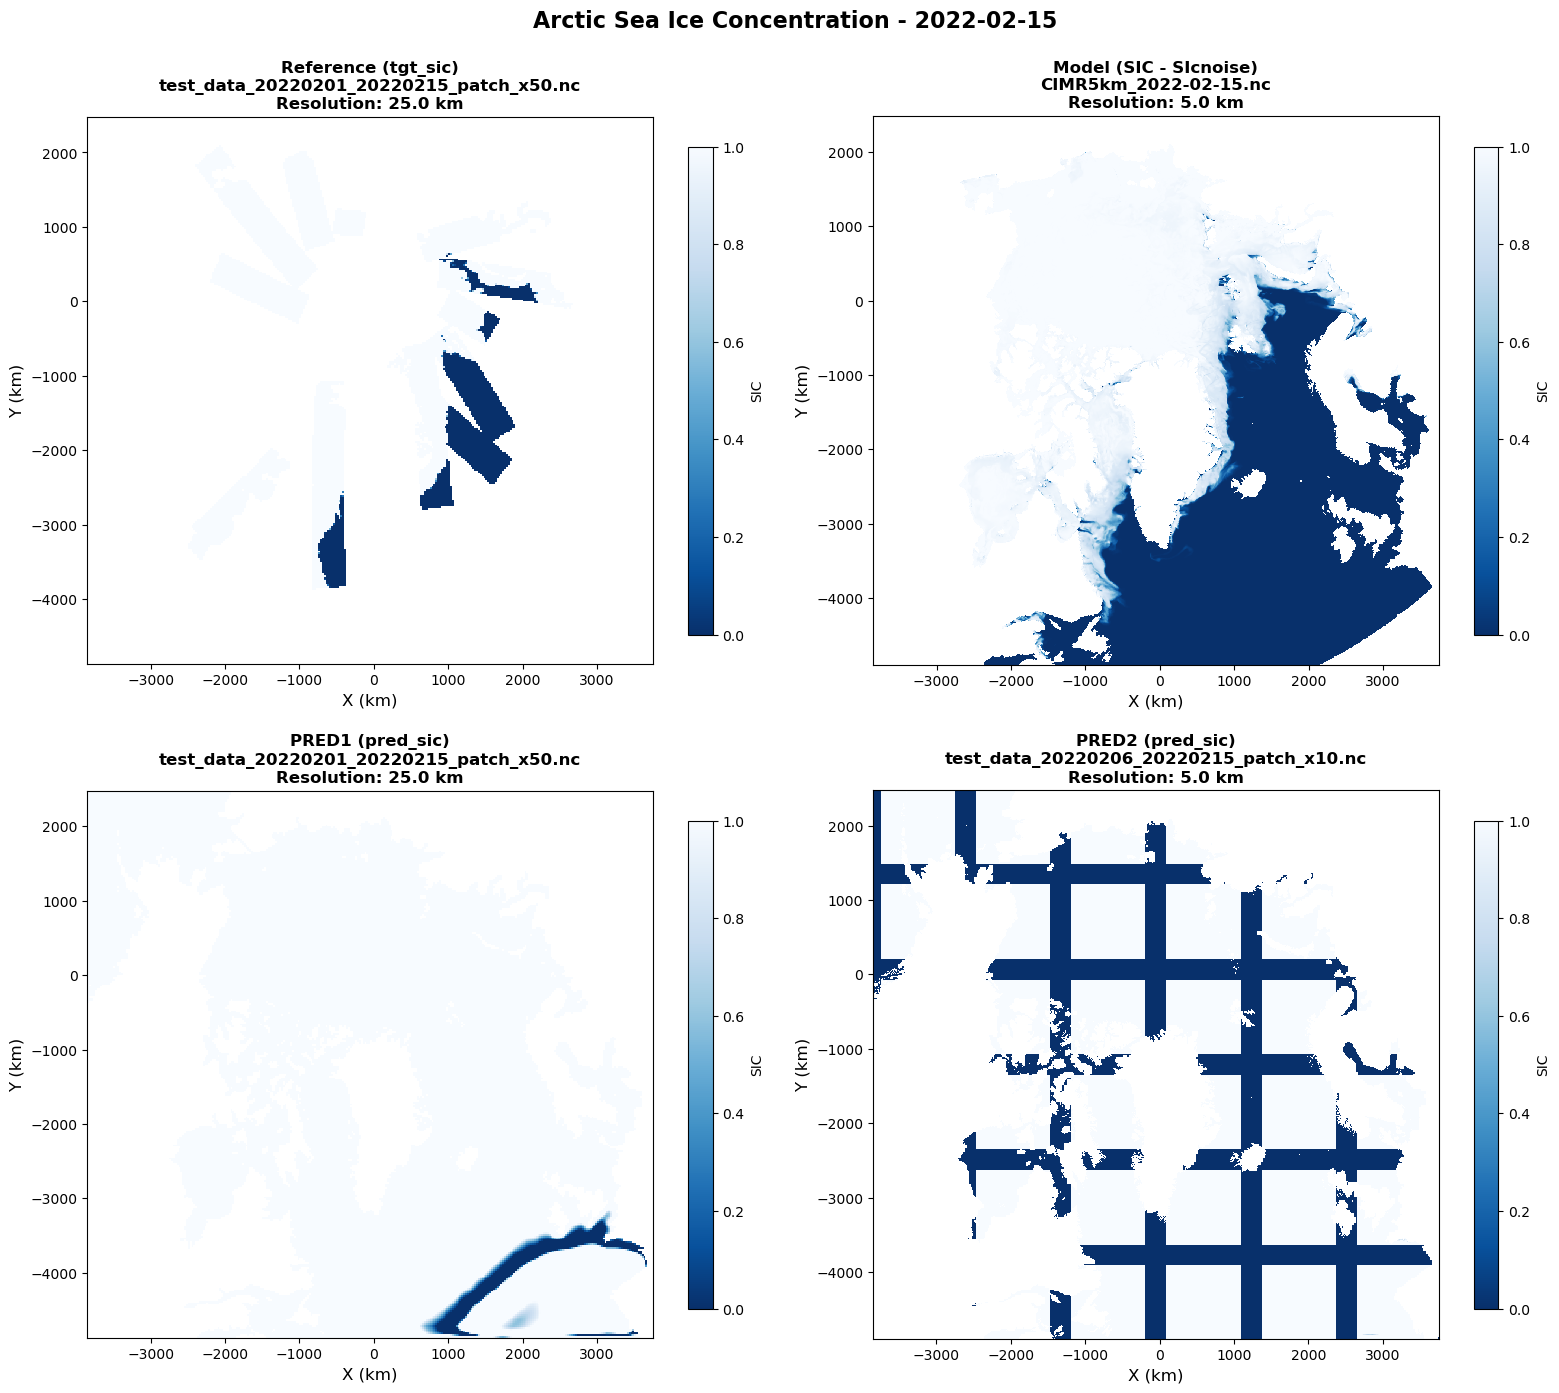


✓ All datasets visualization saved to /data/users/maxb/arctic_all_datasets_comparison.png

DATASET STATISTICS

Reference:
  Min: 0.0000
  Max: 100.0000
  Mean: 72.7299
  NaN%: 86.92%

Model:
  Min: -0.0509
  Max: 1.0559
  Mean: 0.4832
  NaN%: 54.63%

pred1:
  Min: 0.0000
  Max: 100.0000
  Mean: 42.0598
  NaN%: 44.39%

pred2:
  Min: 0.0000
  Max: 100.0000
  Mean: 27.5457
  NaN%: 48.92%


In [4]:
# Visualize all datasets: Reference, Model, and Predictions
if arctic_data['reference'] is not None:
    # Determine number of datasets to plot
    n_preds = len(arctic_data['predictions'])
    has_model = arctic_data['model'] is not None
    
    # Create figure with appropriate layout
    if has_model:
        fig, axes = plt.subplots(2, 2, figsize=(16, 14))
        axes = axes.flatten()
    else:
        # If no model, adjust layout
        n_total = 1 + n_preds  # reference + predictions
        ncols = 2
        nrows = (n_total + 1) // 2
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, 7*nrows))
        axes = axes.flatten() if nrows > 1 else [axes] if n_total == 1 else axes
    
    plot_idx = 0
    
    # Plot 1: Reference
    xc_ref = arctic_data['grid_info']['reference']['xc'] / 1000
    yc_ref = arctic_data['grid_info']['reference']['yc'] / 1000
    X_ref, Y_ref = np.meshgrid(xc_ref, yc_ref, indexing='ij')
    
    im = axes[plot_idx].pcolormesh(X_ref, Y_ref, arctic_data['reference'].T,
                                    cmap='Blues_r', vmin=0, vmax=1, shading='nearest')
    axes[plot_idx].set_xlabel('X (km)', fontsize=12)
    axes[plot_idx].set_ylabel('Y (km)', fontsize=12)
    axes[plot_idx].set_title(f'Reference (tgt_sic)\n{ref_meta["filename"]}\nResolution: {ref_meta["resolution_km"]:.1f} km', 
                              fontsize=12, fontweight='bold')
    axes[plot_idx].set_aspect('equal')
    plt.colorbar(im, ax=axes[plot_idx], label='SIC', shrink=0.8)
    plot_idx += 1
    
    # Plot 2: Model (if available)
    if has_model:
        xc_model = arctic_data['grid_info']['model']['xc'] / 1000
        yc_model = arctic_data['grid_info']['model']['yc'] / 1000
        X_model, Y_model = np.meshgrid(xc_model, yc_model, indexing='ij')
        
        im = axes[plot_idx].pcolormesh(X_model, Y_model, arctic_data['model'].T,
                                        cmap='Blues_r', vmin=0, vmax=1, shading='nearest')
        axes[plot_idx].set_xlabel('X (km)', fontsize=12)
        axes[plot_idx].set_ylabel('Y (km)', fontsize=12)
        axes[plot_idx].set_title(f'Model (SIC - SIcnoise)\n{os.path.basename(cimr_model_file)}\nResolution: {arctic_data["grid_info"]["model"]["dx"]:.1f} km', 
                                  fontsize=12, fontweight='bold')
        axes[plot_idx].set_aspect('equal')
        plt.colorbar(im, ax=axes[plot_idx], label='SIC', shrink=0.8)
        plot_idx += 1
    
    # Plot predictions
    for pred_name in sorted(arctic_data['predictions'].keys()):
        if plot_idx >= len(axes):
            break
            
        pred_data = arctic_data['predictions'][pred_name]
        grid_info = arctic_data['grid_info'][pred_name]
        
        xc_pred = grid_info['xc'] / 1000
        yc_pred = grid_info['yc'] / 1000
        X_pred, Y_pred = np.meshgrid(xc_pred, yc_pred, indexing='ij')
        
        im = axes[plot_idx].pcolormesh(X_pred, Y_pred, pred_data.T,
                                        cmap='Blues_r', vmin=0, vmax=1, shading='nearest')
        axes[plot_idx].set_xlabel('X (km)', fontsize=12)
        axes[plot_idx].set_ylabel('Y (km)', fontsize=12)
        
        # Find filename for this prediction
        pred_idx = int(pred_name.replace('pred', '')) - 1
        pred_filename = file_metadata[pred_idx]['filename'] if pred_idx < len(file_metadata) else 'Unknown'
        
        axes[plot_idx].set_title(f'{pred_name.upper()} (pred_sic)\n{pred_filename}\nResolution: {grid_info["resolution_km"]:.1f} km', 
                                  fontsize=12, fontweight='bold')
        axes[plot_idx].set_aspect('equal')
        plt.colorbar(im, ax=axes[plot_idx], label='SIC', shrink=0.8)
        plot_idx += 1
    
    # Hide unused subplots
    for idx in range(plot_idx, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Arctic Sea Ice Concentration - {target_date[:10]}', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('/data/users/maxb/arctic_all_datasets_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ All datasets visualization saved to /data/users/maxb/arctic_all_datasets_comparison.png")
    
    # Print summary statistics
    print("\n" + "="*80)
    print("DATASET STATISTICS")
    print("="*80)
    
    print(f"\nReference:")
    print(f"  Min: {np.nanmin(arctic_data['reference']):.4f}")
    print(f"  Max: {np.nanmax(arctic_data['reference']):.4f}")
    print(f"  Mean: {np.nanmean(arctic_data['reference']):.4f}")
    print(f"  NaN%: {100 * np.isnan(arctic_data['reference']).sum() / arctic_data['reference'].size:.2f}%")
    
    if has_model:
        print(f"\nModel:")
        print(f"  Min: {np.nanmin(arctic_data['model']):.4f}")
        print(f"  Max: {np.nanmax(arctic_data['model']):.4f}")
        print(f"  Mean: {np.nanmean(arctic_data['model']):.4f}")
        print(f"  NaN%: {100 * np.isnan(arctic_data['model']).sum() / arctic_data['model'].size:.2f}%")
    
    for pred_name in sorted(arctic_data['predictions'].keys()):
        pred_data = arctic_data['predictions'][pred_name]
        print(f"\n{pred_name}:")
        print(f"  Min: {np.nanmin(pred_data):.4f}")
        print(f"  Max: {np.nanmax(pred_data):.4f}")
        print(f"  Mean: {np.nanmean(pred_data):.4f}")
        print(f"  NaN%: {100 * np.isnan(pred_data).sum() / pred_data.size:.2f}%")

## 1. Update Segments Class for Cartesian Coordinates

Modified Segments class to work with regular x/y grids instead of geographic coordinates. Uses Euclidean distance calculations instead of geodesic operations.

In [5]:
class SegmentsCartesian:
    """
    Segments class adapted for Cartesian x/y coordinate systems.
    Designed for Arctic grids with regular spacing in x/y (e.g., polar stereographic).
    
    Parameters
    ----------
    num_segments : int
        Number of random segments to generate
    min_dist : float
        Minimum segment length in kilometers
    max_dist : float
        Maximum segment length in kilometers
    overlapping : float
        Overlap fraction between segments (0-1)
    dx : float
        Grid spacing in x-direction (kilometers)
    dy : float
        Grid spacing in y-direction (kilometers)
    """
    
    def __init__(self, num_segments=1000, min_dist=200, max_dist=1000, 
                 overlapping=0.25, dx=2.2, dy=2.2):
        self.num_segments = num_segments
        self.min_dist = min_dist
        self.max_dist = max_dist
        self.overlapping = overlapping
        self.dx = dx  # Grid spacing in km
        self.dy = dy  # Grid spacing in km
        
    def find_point_cartesian(self, point_idx, angle, dist_km):
        """
        Find endpoint in Cartesian coordinates.
        
        Parameters
        ----------
        point_idx : tuple
            Starting point as (x_idx, y_idx) grid indices
        angle : float
            Angle in degrees (0° = East, 90° = North)
        dist_km : float
            Distance in kilometers
            
        Returns
        -------
        tuple
            Endpoint as (x_idx, y_idx) grid indices
        """
        x_idx, y_idx = point_idx
        angle_rad = np.radians(angle)
        
        # Convert distance to grid indices
        dx_cells = (dist_km * np.cos(angle_rad)) / self.dx
        dy_cells = (dist_km * np.sin(angle_rad)) / self.dy
        
        x_end = int(x_idx + dx_cells)
        y_end = int(y_idx + dy_cells)
        
        return x_end, y_end
    
    def get_idx_pt_endline(self, x1, y1, theta, distance_km):
        """
        Get endpoint indices for a line segment.
        
        Parameters
        ----------
        x1, y1 : int
            Starting grid indices
        theta : float
            Angle in degrees
        distance_km : float
            Distance in kilometers
            
        Returns
        -------
        tuple
            (x2, y2) endpoint grid indices
        """
        return self.find_point_cartesian((x1, y1), theta, distance_km)
    
    def compute_spatial_segment(self, time, x, y, obs, rec):
        """
        Compute spatial segments on Cartesian grid.
        
        Parameters
        ----------
        time : array
            Time coordinates
        x : array
            X-coordinates (1D array, can be in any units)
        y : array
            Y-coordinates (1D array, can be in any units)
        obs : array
            Observation data (time, y, x)
        rec : array
            Reconstruction data (time, y, x)
            
        Returns
        -------
        tuple
            (time_segments, x_segments, y_segments, obs_segments, rec_segments)
        """
        Nx = len(x)
        Ny = len(y)
        mesh_x, mesh_y = np.meshgrid(x, y)
        mesh_x = mesh_x.T
        mesh_y = mesh_y.T
        Nt = len(time)
        
        time_segments = []
        x_segments = []
        y_segments = []
        obs_segments = []
        rec_segments = []
        
        n_segments = 0
        while n_segments < self.num_segments:
            # Generate random starting points
            start_x = np.random.randint(Nx, size=1000)
            start_y = np.random.randint(Ny, size=1000)
            theta = np.random.randint(360, size=1000)
            distance = np.random.randint(self.min_dist, self.max_dist + 100, size=1000)
            
            # Calculate endpoints
            x2_y2 = [self.get_idx_pt_endline(x1, y1, angle, dist) 
                     for x1, y1, angle, dist in zip(start_x, start_y, theta, distance)]
            end_x = [xy[0] for xy in x2_y2]
            end_y = [xy[1] for xy in x2_y2]
            
            # Generate overlapping segments
            ovlp_distance = distance * (1 - self.overlapping)
            ovlp_start_x_start_y = [self.get_idx_pt_endline(x1, y1, angle, dist) 
                                    for x1, y1, angle, dist in 
                                    zip(start_x, start_y, theta, ovlp_distance)]
            ovlp_start_x = [xy[0] for xy in ovlp_start_x_start_y if xy[0] < Nx]
            ovlp_start_y = [xy[1] for xy in ovlp_start_x_start_y if xy[1] < Ny]
            
            ovlp_end_x_end_y = [self.get_idx_pt_endline(x1, y1, angle, dist) 
                                for x1, y1, angle, dist in 
                                zip(ovlp_start_x, ovlp_start_y, theta, distance)]
            ovlp_end_x = [xy[0] for xy in ovlp_end_x_end_y]
            ovlp_end_y = [xy[1] for xy in ovlp_end_x_end_y]
            
            # Concatenate candidates
            start_x = np.concatenate((start_x, ovlp_start_x))
            start_y = np.concatenate((start_y, ovlp_start_y))
            end_x = np.concatenate((end_x, ovlp_end_x))
            end_y = np.concatenate((end_y, ovlp_end_y))
            
            # Generate line coordinates
            line_in_img = zip(start_x, start_y, end_x, end_y)
            rr_cc = [line(*l) for l in line_in_img]
            rr = [c[0] for c in rr_cc]
            cc = [c[1] for c in rr_cc]
            
            # Random time selection
            tt = np.random.randint(Nt, size=len(cc))
            
            # Filter valid segments - check ALL points are in bounds
            def is_valid_segment(r, c):
                """Check if all points in segment are within bounds"""
                return (np.all(r >= 0) and np.all(r < Nx) and 
                       np.all(c >= 0) and np.all(c < Ny))
            
            valid_mask = [is_valid_segment(r, c) for r, c in zip(rr, cc)]
            
            time_segment = [t for t, valid in zip(tt, valid_mask) if valid]
            x_segment = [mesh_x[r, c] for r, c, valid in zip(rr, cc, valid_mask) if valid]
            y_segment = [mesh_y[r, c] for r, c, valid in zip(rr, cc, valid_mask) if valid]
            obs_segment = [obs[t, c, r] for t, r, c, valid in zip(tt, rr, cc, valid_mask) if valid]
            rec_segment = [rec[t, c, r] for t, r, c, valid in zip(tt, rr, cc, valid_mask) if valid]
            
            if len(obs_segment) > 0:
                # Check for NaN values
                ratio_nan_obs = [100 * (1 - np.mean(np.isfinite(s))) for s in obs_segment]
                ratio_nan_rec = [100 * (1 - np.mean(np.isfinite(s))) for s in rec_segment]
                
                # Select valid segments
                idx_valid = [i for i in range(len(obs_segment)) 
                            if (ratio_nan_obs[i] == 0. and 
                                ratio_nan_rec[i] == 0. and 
                                len(x_segment[i]) >= self.min_dist / self.dx)]
                
                if len(idx_valid) > 0:
                    time_segments += [time_segment[i] for i in idx_valid]
                    x_segments += [x_segment[i] for i in idx_valid]
                    y_segments += [y_segment[i] for i in idx_valid]
                    obs_segments += [obs_segment[i] for i in idx_valid]
                    rec_segments += [rec_segment[i] for i in idx_valid]
            
            n_segments = len(x_segments)
            if n_segments % 100 == 0:
                print(f"Generated {n_segments} segments")
        
        # Standardize segment lengths
        nperseg = np.min([len(x_segments[i]) for i in range(len(x_segments))])
        x_segments = [x_segments[i][:nperseg] for i in range(len(x_segments))]
        y_segments = [y_segments[i][:nperseg] for i in range(len(y_segments))]
        obs_segments = [obs_segments[i][:nperseg] for i in range(len(obs_segments))]
        rec_segments = [rec_segments[i][:nperseg] for i in range(len(rec_segments))]
        
        return time_segments, x_segments, y_segments, obs_segments, rec_segments
        
    def compute_time_segment(self, time, x, y, obs, rec, criteria="rec"):
        """
        Compute temporal segments on Cartesian grid.
        
        Parameters
        ----------
        time : array
            Time coordinates
        x : array
            X-coordinates
        y : array
            Y-coordinates
        obs : array
            Observation data (time, y, x)
        rec : array
            Reconstruction data (time, y, x)
        criteria : str
            Validation criteria ('rec' or 'obs')
            
        Returns
        -------
        tuple
            (time_segments, x_segments, y_segments, obs_segments, rec_segments)
        """
        Nx = len(x)
        Ny = len(y)
        mesh_x, mesh_y = np.meshgrid(x, y)
        mesh_x = mesh_x.T
        mesh_y = mesh_y.T
        Nt = len(time)
        mesh_time = np.arange(Nt)
        
        time_segments = []
        x_segments = []
        y_segments = []
        obs_segments = []
        rec_segments = []
        
        n_segments = 0
        while n_segments < self.num_segments:
            start_t = np.random.randint(Nt, size=1000)
            distance = np.random.randint(self.max_dist, self.max_dist + 5, size=1000)
            
            # Overlapping segments
            ovlp_t = [t + int(d * (1 - self.overlapping)) for t, d in zip(start_t, distance)]
            
            # Concatenate
            start_t = np.concatenate((start_t, ovlp_t))
            end_t = [t + d for t, d in zip(start_t, np.concatenate((distance, distance)))]
            
            # Random spatial positions
            x_idx = np.random.randint(Nx, size=len(start_t))
            y_idx = np.random.randint(Ny, size=len(start_t))
            
            # Generate segments
            time_segment = [mesh_time[ts:te] for ts, te in zip(start_t, end_t) if te < Nt]
            x_segment = [mesh_x[r, c] for ts, te, r, c in zip(start_t, end_t, x_idx, y_idx) if te < Nt]
            y_segment = [mesh_y[r, c] for ts, te, r, c in zip(start_t, end_t, x_idx, y_idx) if te < Nt]
            obs_segment = [obs[ts:te, c, r] for ts, te, r, c in zip(start_t, end_t, x_idx, y_idx) if te < Nt]
            rec_segment = [rec[ts:te, c, r] for ts, te, r, c in zip(start_t, end_t, x_idx, y_idx) if te < Nt]
            
            if len(obs_segment) > 0:
                ratio_nan_obs = [100 * (1 - np.mean(np.isfinite(s))) for s in obs_segment]
                ratio_nan_rec = [100 * (1 - np.mean(np.isfinite(s))) for s in rec_segment]
                
                if criteria != "rec":
                    idx_valid = [i for i in range(len(obs_segment)) 
                                if (ratio_nan_obs[i] == 0. and 
                                    ratio_nan_rec[i] == 0. and 
                                    len(time_segment[i]) >= self.max_dist)]
                else:
                    idx_valid = [i for i in range(len(obs_segment)) 
                                if (ratio_nan_rec[i] == 0. and 
                                    len(time_segment[i]) >= self.max_dist)]
                
                if len(idx_valid) > 0:
                    time_segments += [time_segment[i] for i in idx_valid]
                    x_segments += [x_segment[i] for i in idx_valid]
                    y_segments += [y_segment[i] for i in idx_valid]
                    obs_segments += [obs_segment[i] for i in idx_valid]
                    rec_segments += [rec_segment[i] for i in idx_valid]
            
            n_segments = len(x_segments)
            if n_segments % 100 == 0:
                print(f"Generated {n_segments} segments")
        
        # Standardize
        nperseg = np.min([len(time_segments[i]) for i in range(len(time_segments))])
        time_segments = [time_segments[i][:nperseg] for i in range(len(time_segments))]
        obs_segments = [obs_segments[i][:nperseg] for i in range(len(obs_segments))]
        rec_segments = [rec_segments[i][:nperseg] for i in range(len(rec_segments))]
        
        return time_segments, x_segments, y_segments, obs_segments, rec_segments

## 2. Modify Spectral Score Computation

Adapted compute_spectral_scores function to work with x/y coordinates and grid spacing in kilometers.

In [6]:
def compute_spectral_scores_cartesian(time, 
                                     x, 
                                     y, 
                                     obs, 
                                     rec, 
                                     mode,
                                     delta,
                                     output_filename,
                                     min_dist=200,
                                     max_dist=400,
                                     dx=2.2,
                                     dy=2.2):
    """
    Compute spectral scores for Cartesian grids (e.g., Arctic projections).
    
    Parameters
    ----------
    time : array
        Time coordinates
    x : array
        X-coordinates (1D array)
    y : array
        Y-coordinates (1D array)
    obs : array
        Observation data (time, y, x)
    rec : array
        Reconstruction data (time, y, x)
    mode : str
        'spatial' or 'temporal'
    delta : float
        Spatial or temporal resolution (km for spatial, days for temporal)
    output_filename : str
        Path to save output NetCDF file
    min_dist : float
        Minimum segment distance (km for spatial, days for temporal)
    max_dist : float
        Maximum segment distance (km for spatial, days for temporal)
    dx : float
        Grid spacing in x-direction (km)
    dy : float
        Grid spacing in y-direction (km)
    """
    
    if mode == "spatial":
        segments_spatial = SegmentsCartesian(
            num_segments=500, 
            min_dist=min_dist, 
            max_dist=max_dist,
            dx=dx,
            dy=dy
        )
        time_segment, x_segment, y_segment, obs_sst_segment, rec_sst_segment = \
            segments_spatial.compute_spatial_segment(time, x, y, obs, rec)
        npt = len(obs_sst_segment[0])
        
    elif mode == "temporal":
        segments_temporal = SegmentsCartesian(
            num_segments=1000, 
            max_dist=max_dist,
            dx=dx,
            dy=dy
        )
        time_segment, x_segment, y_segment, obs_sst_segment, rec_sst_segment = \
            segments_temporal.compute_time_segment(time, x, y, obs, rec)
        npt = len(obs_sst_segment[0])
    else:
        raise ValueError("mode must be 'spatial' or 'temporal'")
    
    # Compute power spectral density for reference field
    global_wavenumber, global_psd_ref = scipy.signal.welch(
        np.asarray(obs_sst_segment).flatten(),
        fs=1.0 / delta,
        nperseg=npt,
        scaling='density',
        detrend="linear",
        noverlap=0
    )
    
    # Compute PSD for study field
    _, global_psd_study = scipy.signal.welch(
        np.asarray(rec_sst_segment).flatten(),
        fs=1.0 / delta,
        nperseg=npt,
        scaling='density',
        detrend="linear",
        noverlap=0
    )
    
    # Compute PSD for difference
    _, global_psd_diff = scipy.signal.welch(
        np.asarray(rec_sst_segment).flatten() - np.asarray(obs_sst_segment).flatten(),
        fs=1.0 / delta,
        nperseg=npt,
        scaling='density',
        detrend="linear",
        noverlap=0
    )
    
    # Save PSD to NetCDF
    ds = xr.Dataset(
        {
            "psd_ref": (["wavenumber"], global_psd_ref),
            "psd_study": (["wavenumber"], global_psd_study),
            "psd_diff": (["wavenumber"], global_psd_diff),
        },
        coords={"wavenumber": (["wavenumber"], global_wavenumber)},
    )
    
    ds.to_netcdf(output_filename)
    logging.info(f"Spectral scores saved to {output_filename}")

## 3. Create Helper Functions for Coordinate Conversion

Utility functions for working with Cartesian grids and converting between indices and physical distances.

In [7]:
def calculate_grid_spacing(x, y, units='km'):
    """
    Calculate grid spacing from coordinate arrays.
    
    Parameters
    ----------
    x : array
        X-coordinates
    y : array
        Y-coordinates
    units : str
        Units of input coordinates ('km', 'm', or 'grid')
        
    Returns
    -------
    tuple
        (dx, dy) grid spacing in kilometers
    """
    dx = np.mean(np.diff(x))
    dy = np.mean(np.diff(y))
    
    if units == 'm':
        dx = dx / 1000.0
        dy = dy / 1000.0
    elif units == 'grid':
        logging.warning("Grid units specified - assuming 1 grid unit = 1 km")
        
    logging.info(f"Grid spacing: dx={dx:.2f} km, dy={dy:.2f} km")
    return dx, dy


def segment_length_km(segment_indices, dx, dy):
    """
    Calculate physical length of a segment in kilometers.
    
    Parameters
    ----------
    segment_indices : array
        Segment as array of (x_idx, y_idx) pairs
    dx : float
        Grid spacing in x-direction (km)
    dy : float
        Grid spacing in y-direction (km)
        
    Returns
    -------
    float
        Segment length in kilometers
    """
    if len(segment_indices) < 2:
        return 0.0
    
    total_length = 0.0
    for i in range(len(segment_indices) - 1):
        x1, y1 = segment_indices[i]
        x2, y2 = segment_indices[i + 1]
        
        dx_cells = abs(x2 - x1)
        dy_cells = abs(y2 - y1)
        
        length = np.sqrt((dx_cells * dx)**2 + (dy_cells * dy)**2)
        total_length += length
    
    return total_length


def validate_segments_cartesian(x_segments, y_segments, x, y, min_length_km, dx, dy):
    """
    Validate segments have sufficient length and are within grid bounds.
    
    Parameters
    ----------
    x_segments : list
        List of x-coordinate segments
    y_segments : list
        List of y-coordinate segments
    x : array
        Full x-coordinate array
    y : array
        Full y-coordinate array
    min_length_km : float
        Minimum required segment length in km
    dx : float
        Grid spacing in x-direction (km)
    dy : float
        Grid spacing in y-direction (km)
        
    Returns
    -------
    list
        Indices of valid segments
    """
    valid_indices = []
    
    for i, (x_seg, y_seg) in enumerate(zip(x_segments, y_segments)):
        # Check bounds
        if (np.min(x_seg) < np.min(x) or np.max(x_seg) > np.max(x) or
            np.min(y_seg) < np.min(y) or np.max(y_seg) > np.max(y)):
            continue
        
        # Check length (approximate)
        if len(x_seg) * dx < min_length_km:
            continue
            
        valid_indices.append(i)
    
    logging.info(f"Validated {len(valid_indices)}/{len(x_segments)} segments")
    return valid_indices


def convert_xy_to_indices(x_coords, y_coords, x_array, y_array):
    """
    Convert x/y physical coordinates to grid indices.
    
    Parameters
    ----------
    x_coords : array
        X-coordinates to convert
    y_coords : array
        Y-coordinates to convert
    x_array : array
        Reference x-coordinate array
    y_array : array
        Reference y-coordinate array
        
    Returns
    -------
    tuple
        (x_indices, y_indices)
    """
    x_indices = np.searchsorted(x_array, x_coords)
    y_indices = np.searchsorted(y_array, y_coords)
    
    # Clip to valid range
    x_indices = np.clip(x_indices, 0, len(x_array) - 1)
    y_indices = np.clip(y_indices, 0, len(y_array) - 1)
    
    return x_indices, y_indices

## 4. Test with Arctic Grid Data

Real Arctic sea ice concentration data analysis using reference, model, and predictions.

In [8]:
# Prepare real Arctic data for spectral analysis
import os

print("="*80)
print("PREPARING ARCTIC DATA FOR SPECTRAL ANALYSIS")
print("="*80)

# Initialize dictionaries for spectral analysis
spectral_data = {}

# 1. Reference data (coarsest resolution)
ref_grid = arctic_data['grid_info']['reference']
ref_data_prepared = arctic_data['reference'].copy()

# Add time dimension (single timestep for this analysis)
ref_data_3d = ref_data_prepared[np.newaxis, :, :]  # Shape: (1, ny, nx)
time_coord = np.array([0])  # Single time step

spectral_data['reference'] = {
    'time': time_coord,
    'x': ref_grid['xc'],
    'y': ref_grid['yc'],
    'obs': ref_data_3d,
    'dx': ref_grid['dx'],
    'dy': ref_grid['dy'],
    'resolution_km': ref_grid['resolution_km']
}

print(f"\n✓ Reference prepared:")
print(f"  Shape: {ref_data_3d.shape} (time, y, x)")
print(f"  Resolution: {ref_grid['resolution_km']:.1f} km")
print(f"  Grid spacing: dx={ref_grid['dx']:.2f}, dy={ref_grid['dy']:.2f} km")

# 2. Model data
if arctic_data['model'] is not None:
    model_grid = arctic_data['grid_info']['model']
    model_data_prepared = arctic_data['model'].copy()
    model_data_3d = model_data_prepared[np.newaxis, :, :]
    
    spectral_data['model'] = {
        'time': time_coord,
        'x': model_grid['xc'],
        'y': model_grid['yc'],
        'rec': model_data_3d,
        'obs': ref_data_3d,  # Use reference as obs
        'dx': model_grid['dx'],
        'dy': model_grid['dy'],
        'resolution_km': model_grid['dx']
    }
    
    print(f"\n✓ Model prepared:")
    print(f"  Shape: {model_data_3d.shape} (time, y, x)")
    print(f"  Resolution: {model_grid['dx']:.1f} km")
    print(f"  Grid spacing: dx={model_grid['dx']:.2f}, dy={model_grid['dy']:.2f} km")

# 3. Predictions
for pred_name in sorted(arctic_data['predictions'].keys()):
    pred_grid = arctic_data['grid_info'][pred_name]
    pred_data_prepared = arctic_data['predictions'][pred_name].copy()
    pred_data_3d = pred_data_prepared[np.newaxis, :, :]
    
    spectral_data[pred_name] = {
        'time': time_coord,
        'x': pred_grid['xc'],
        'y': pred_grid['yc'],
        'rec': pred_data_3d,
        'obs': ref_data_3d,  # Use reference as obs
        'dx': pred_grid['dx'],
        'dy': pred_grid['dy'],
        'resolution_km': pred_grid['resolution_km']
    }
    
    print(f"\n✓ {pred_name.upper()} prepared:")
    print(f"  Shape: {pred_data_3d.shape} (time, y, x)")
    print(f"  Resolution: {pred_grid['resolution_km']:.1f} km")
    print(f"  Grid spacing: dx={pred_grid['dx']:.2f}, dy={pred_grid['dy']:.2f} km")

print("\n" + "="*80)
print(f"✓ {len(spectral_data)} DATASETS PREPARED FOR SPECTRAL ANALYSIS")
print("="*80)

PREPARING ARCTIC DATA FOR SPECTRAL ANALYSIS

✓ Reference prepared:
  Shape: (1, 294, 304) (time, y, x)
  Resolution: 25.0 km
  Grid spacing: dx=25.00, dy=25.00 km

✓ Model prepared:
  Shape: (1, 1475, 1520) (time, y, x)
  Resolution: 5.0 km
  Grid spacing: dx=5.00, dy=5.00 km

✓ PRED1 prepared:
  Shape: (1, 294, 304) (time, y, x)
  Resolution: 25.0 km
  Grid spacing: dx=25.00, dy=25.00 km

✓ PRED2 prepared:
  Shape: (1, 1474, 1520) (time, y, x)
  Resolution: 5.0 km
  Grid spacing: dx=5.00, dy=5.00 km

✓ 4 DATASETS PREPARED FOR SPECTRAL ANALYSIS


In [9]:
# Generate segments for each dataset
print("\n" + "="*80)
print("GENERATING SPATIAL SEGMENTS")
print("="*80)

segments_data = {}

for dataset_name, data in spectral_data.items():
    print(f"\n{dataset_name.upper()}:")
    print(f"  Grid: {len(data['x'])} x {len(data['y'])}")
    print(f"  Resolution: {data['resolution_km']:.1f} km")
    
    # Adjust segment parameters based on grid resolution
    min_dist = max(100, data['resolution_km'] * 20)
    max_dist = max(300, data['resolution_km'] * 50)
    
    print(f"  Segment range: {min_dist:.0f} - {max_dist:.0f} km")
    
    # Create segments
    segments = SegmentsCartesian(
        num_segments=200,  # Reduced for faster processing
        min_dist=min_dist,
        max_dist=max_dist,
        dx=data['dx'],
        dy=data['dy']
    )
    
    try:
        # For model and predictions, use 'rec' field
        if dataset_name == 'reference':
            # Reference only has obs data
            obs_field = data['obs']
            rec_field = data['obs']  # Use same for both
        else:
            obs_field = data['obs']
            rec_field = data['rec']
        
        time_seg, x_seg, y_seg, obs_seg, rec_seg = segments.compute_spatial_segment(
            data['time'],
            data['x'],
            data['y'],
            obs_field,
            rec_field
        )
        
        segments_data[dataset_name] = {
            'time': time_seg,
            'x': x_seg,
            'y': y_seg,
            'obs': obs_seg,
            'rec': rec_seg,
            'count': len(x_seg),
            'length': len(x_seg[0]) if len(x_seg) > 0 else 0
        }
        
        print(f"  ✓ Generated {len(x_seg)} valid segments")
        if len(x_seg) > 0:
            print(f"    Segment length: {len(x_seg[0])} points (~{len(x_seg[0]) * data['dx']:.1f} km)")
        
    except Exception as e:
        print(f"  ✗ ERROR: {str(e)}")
        segments_data[dataset_name] = None

print("\n" + "="*80)
print("SEGMENT GENERATION COMPLETE")
print("="*80)


GENERATING SPATIAL SEGMENTS

REFERENCE:
  Grid: 304 x 294
  Resolution: 25.0 km
  Segment range: 500 - 1250 km
Generated 200 segments
  ✓ Generated 200 valid segments
    Segment length: 20 points (~500.0 km)

MODEL:
  Grid: 1520 x 1475
  Resolution: 5.0 km
  Segment range: 100 - 300 km
  ✗ ERROR: index 1463 is out of bounds for axis 1 with size 294

PRED1:
  Grid: 304 x 294
  Resolution: 25.0 km
  Segment range: 500 - 1250 km
Generated 200 segments
  ✓ Generated 200 valid segments
    Segment length: 20 points (~500.0 km)

PRED2:
  Grid: 1520 x 1474
  Resolution: 5.0 km
  Segment range: 100 - 300 km
  ✗ ERROR: index 1205 is out of bounds for axis 2 with size 304

SEGMENT GENERATION COMPLETE


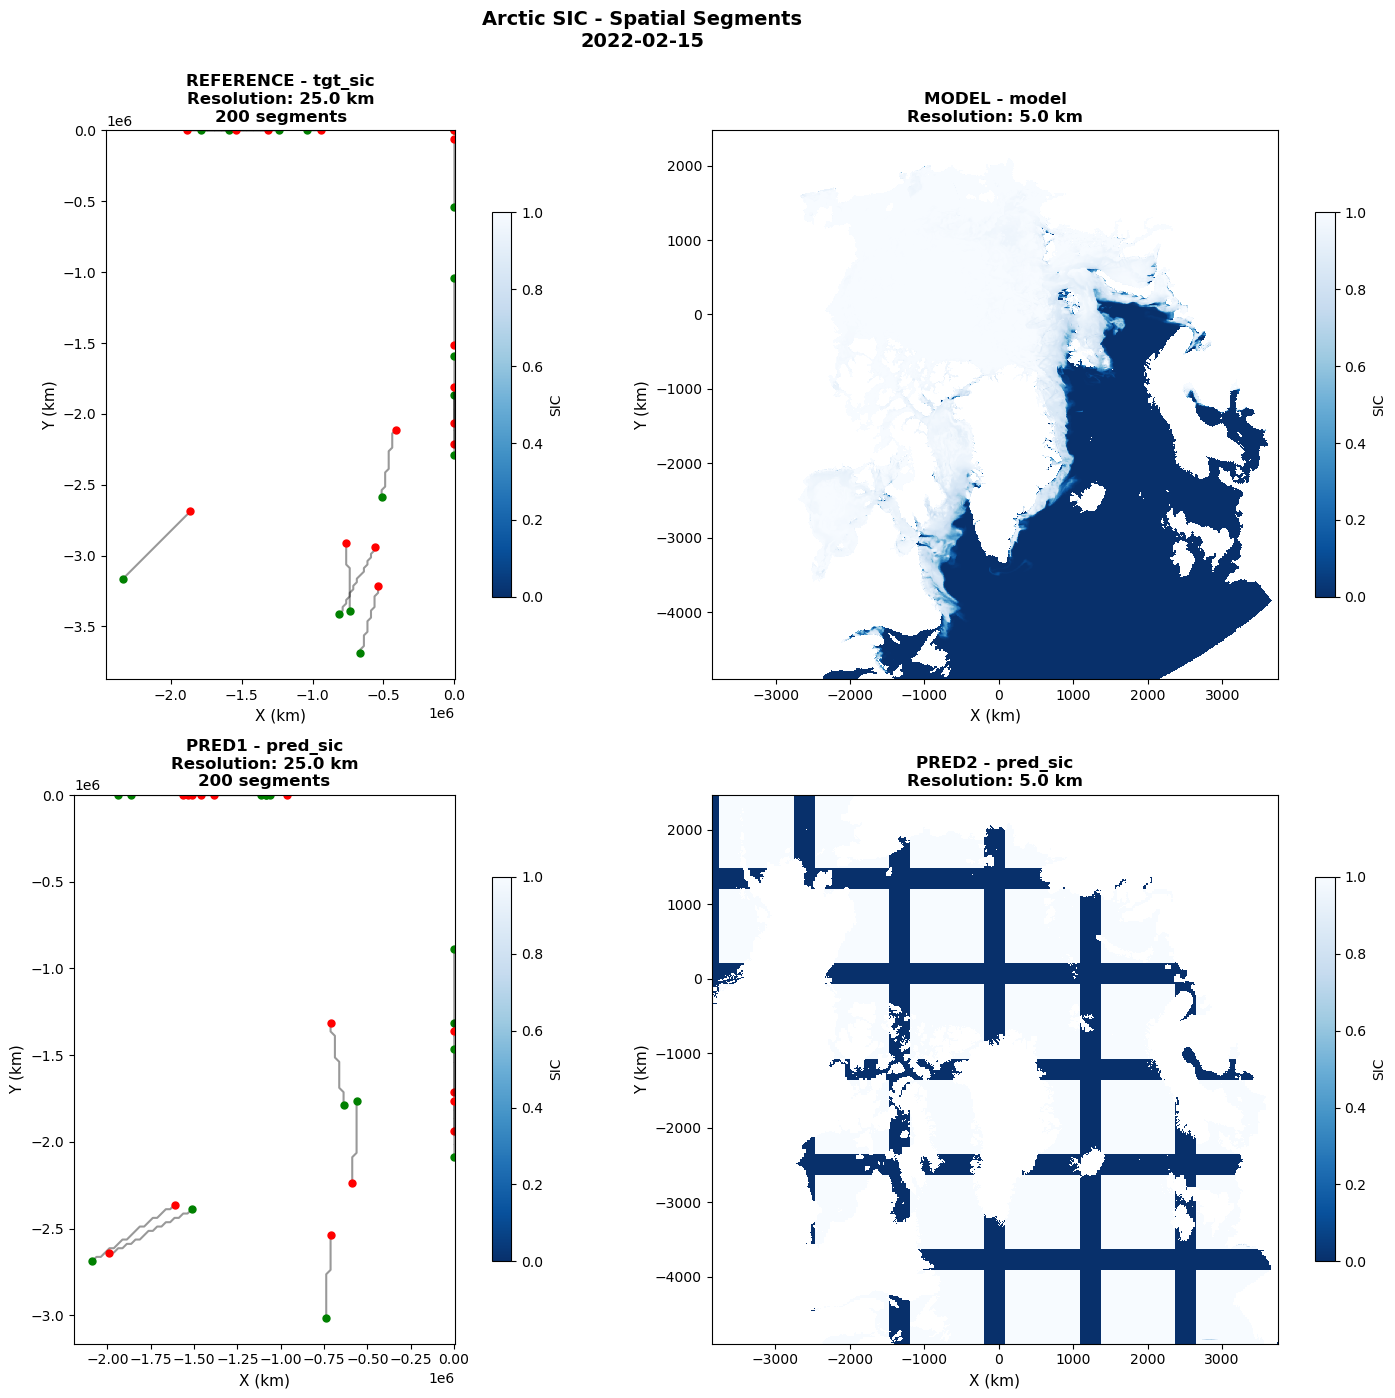


✓ Segments visualization saved to /data/users/maxb/arctic_spatial_segments_all.png


In [10]:
# Visualize segments for each dataset
fig_rows = (len(spectral_data) + 1) // 2
fig, axes = plt.subplots(fig_rows, 2, figsize=(16, 7*fig_rows))
axes = axes.flatten() if fig_rows > 1 else [axes] if len(spectral_data) == 1 else axes

plot_idx = 0
for dataset_name, data in spectral_data.items():
    if plot_idx >= len(axes):
        break
        
    ax = axes[plot_idx]
    
    # Determine which field to plot
    if dataset_name == 'reference':
        plot_field = data['obs'][0]
        field_label = 'tgt_sic'
    else:
        plot_field = data['rec'][0]
        field_label = 'pred_sic' if 'pred' in dataset_name else 'model'
    
    # Convert coordinates to km for plotting
    xc_km = data['x'] / 1000 if np.max(data['x']) > 10000 else data['x']
    yc_km = data['y'] / 1000 if np.max(data['y']) > 10000 else data['y']
    X, Y = np.meshgrid(xc_km, yc_km, indexing='ij')
    
    # Plot field
    im = ax.pcolormesh(X, Y, plot_field.T, cmap='Blues_r', 
                       vmin=0, vmax=1, shading='nearest')
    
    # Overlay segments
    if segments_data.get(dataset_name) is not None:
        seg_data = segments_data[dataset_name]
        n_plot = min(15, seg_data['count'])
        
        for i in range(n_plot):
            x_seg_km = np.array(seg_data['x'][i]) / 1000 if np.max(seg_data['x'][i]) > 10000 else seg_data['x'][i]
            y_seg_km = np.array(seg_data['y'][i]) / 1000 if np.max(seg_data['y'][i]) > 10000 else seg_data['y'][i]
            
            ax.plot(x_seg_km, y_seg_km, 'k-', alpha=0.4, linewidth=1.5)
            ax.plot(x_seg_km[0], y_seg_km[0], 'go', markersize=5)
            ax.plot(x_seg_km[-1], y_seg_km[-1], 'ro', markersize=5)
    
    ax.set_xlabel('X (km)', fontsize=11)
    ax.set_ylabel('Y (km)', fontsize=11)
    title = f'{dataset_name.upper()} - {field_label}\nResolution: {data["resolution_km"]:.1f} km'
    if segments_data.get(dataset_name) is not None:
        title += f'\n{segments_data[dataset_name]["count"]} segments'
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, label='SIC', shrink=0.7)
    
    plot_idx += 1

# Hide unused subplots
for idx in range(plot_idx, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Arctic SIC - Spatial Segments\n{target_date[:10]}', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('/data/users/maxb/arctic_spatial_segments_all.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Segments visualization saved to /data/users/maxb/arctic_spatial_segments_all.png")

In [11]:
# Compute spectral scores for all datasets
print("\n" + "="*80)
print("COMPUTING SPECTRAL SCORES")
print("="*80)

spectral_output_dir = '/data/users/maxb/arctic_spectral_outputs'
os.makedirs(spectral_output_dir, exist_ok=True)

spectral_results = {}

for dataset_name, data in spectral_data.items():
    print(f"\n{dataset_name.upper()}:")
    
    output_file = os.path.join(spectral_output_dir, f'psd_{dataset_name}.nc')
    
    # Determine segment distance parameters
    min_dist = max(100, data['resolution_km'] * 20)
    max_dist = max(300, data['resolution_km'] * 50)
    
    try:
        # For reference, use obs as both obs and rec
        if dataset_name == 'reference':
            obs_field = data['obs']
            rec_field = data['obs']
        else:
            obs_field = data['obs']
            rec_field = data['rec']
        
        compute_spectral_scores_cartesian(
            time=data['time'],
            x=data['x'],
            y=data['y'],
            obs=obs_field,
            rec=rec_field,
            mode='spatial',
            delta=data['dx'],
            output_filename=output_file,
            min_dist=min_dist,
            max_dist=max_dist,
            dx=data['dx'],
            dy=data['dy']
        )
        
        spectral_results[dataset_name] = output_file
        print(f"  ✓ Saved to: {output_file}")
        
    except Exception as e:
        print(f"  ✗ ERROR: {str(e)}")
        spectral_results[dataset_name] = None

print("\n" + "="*80)
print("SPECTRAL SCORE COMPUTATION COMPLETE")
print("="*80)


COMPUTING SPECTRAL SCORES

REFERENCE:
Generated 400 segments


INFO:root:Spectral scores saved to /data/users/maxb/arctic_spectral_outputs/psd_reference.nc


  ✓ Saved to: /data/users/maxb/arctic_spectral_outputs/psd_reference.nc

MODEL:
  ✗ ERROR: index 488 is out of bounds for axis 1 with size 294

PRED1:


INFO:root:Spectral scores saved to /data/users/maxb/arctic_spectral_outputs/psd_pred1.nc


  ✓ Saved to: /data/users/maxb/arctic_spectral_outputs/psd_pred1.nc

PRED2:
  ✗ ERROR: index 1003 is out of bounds for axis 1 with size 294

SPECTRAL SCORE COMPUTATION COMPLETE



VISUALIZING POWER SPECTRAL DENSITIES


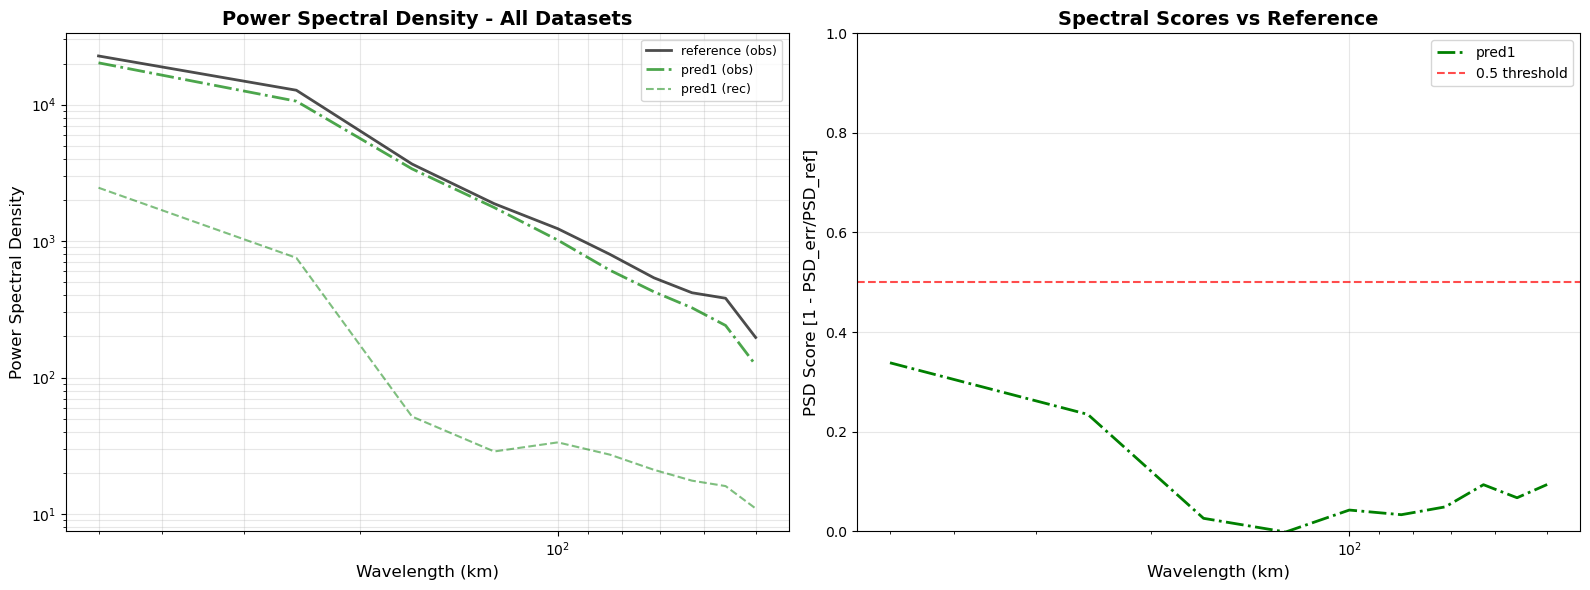


✓ PSD comparison saved to /data/users/maxb/arctic_psd_comparison_all.png


In [12]:
# Visualize all power spectral densities
print("\n" + "="*80)
print("VISUALIZING POWER SPECTRAL DENSITIES")
print("="*80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = {'reference': 'black', 'model': 'blue', 'pred1': 'green', 'pred2': 'orange', 'pred3': 'red'}
linestyles = {'reference': '-', 'model': '--', 'pred1': '-.', 'pred2': ':', 'pred3': '--'}

# Plot PSD
for dataset_name, output_file in spectral_results.items():
    if output_file is None:
        continue
    
    try:
        ds_psd = xr.open_dataset(output_file)
        wavelength = 1.0 / ds_psd.wavenumber
        
        color = colors.get(dataset_name, 'gray')
        ls = linestyles.get(dataset_name, '-')
        
        # PSD plot
        ax1.loglog(wavelength, ds_psd.psd_ref, color=color, linestyle=ls, 
                   label=f'{dataset_name} (obs)', linewidth=2, alpha=0.7)
        if dataset_name != 'reference':
            ax1.loglog(wavelength, ds_psd.psd_study, color=color, linestyle='--',
                       label=f'{dataset_name} (rec)', linewidth=1.5, alpha=0.5)
        
        # PSD score plot
        if dataset_name != 'reference':
            psd_score = 1.0 - ds_psd.psd_diff / ds_psd.psd_ref
            ax2.semilogx(wavelength, psd_score, color=color, linestyle=ls,
                         label=dataset_name, linewidth=2)
        
        ds_psd.close()
        
    except Exception as e:
        print(f"  Warning: Could not plot {dataset_name}: {str(e)}")

# Finalize PSD plot
ax1.set_xlabel('Wavelength (km)', fontsize=12)
ax1.set_ylabel('Power Spectral Density', fontsize=12)
ax1.set_title('Power Spectral Density - All Datasets', fontsize=14, fontweight='bold')
ax1.legend(fontsize=9, loc='best')
ax1.grid(True, alpha=0.3, which='both')
ax1.invert_xaxis()

# Finalize PSD score plot
ax2.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='0.5 threshold')
ax2.set_xlabel('Wavelength (km)', fontsize=12)
ax2.set_ylabel('PSD Score [1 - PSD_err/PSD_ref]', fontsize=12)
ax2.set_title('Spectral Scores vs Reference', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('/data/users/maxb/arctic_psd_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ PSD comparison saved to /data/users/maxb/arctic_psd_comparison_all.png")

In [14]:
# Compute resolved scales for each dataset
print("\n" + "="*80)
print("RESOLVED SCALES ANALYSIS")
print("="*80)

resolved_scales = {}

for dataset_name, output_file in spectral_results.items():
    if output_file is None or dataset_name == 'reference':
        continue
    
    try:
        ds_psd = xr.open_dataset(output_file)
        wavelength = 1.0 / ds_psd.wavenumber
        psd_score = 1.0 - ds_psd.psd_diff / ds_psd.psd_ref
        
        # Find where score crosses 0.5
        psd_score_valid = psd_score.where(np.isfinite(psd_score), drop=True)
        wavelength_valid = wavelength.where(np.isfinite(psd_score), drop=True)
        
        crossing_idx = np.where(psd_score_valid.values < 0.5)[0]
        
        if len(crossing_idx) > 0:
            resolved_scale = wavelength_valid.values[crossing_idx[0]]
            resolved_scales[dataset_name] = resolved_scale
            print(f"\n{dataset_name.upper()}:")
            print(f"  Resolved scale (0.5 crossing): {resolved_scale:.1f} km")
            print(f"  Grid resolution: {spectral_data[dataset_name]['resolution_km']:.1f} km")
            print(f"  Ratio: {resolved_scale / spectral_data[dataset_name]['resolution_km']:.1f}x")
        else:
            resolved_scales[dataset_name] = None
            print(f"\n{dataset_name.upper()}:")
            print(f"  No 0.5 crossing found - all scales resolved")
        
        ds_psd.close()
        
    except Exception as e:
        print(f"  Warning: Could not analyze {dataset_name}: {str(e)}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


RESOLVED SCALES ANALYSIS

PRED1:
  Resolved scale (0.5 crossing): inf km
  Grid resolution: 25.0 km
  Ratio: infx

ANALYSIS COMPLETE


## Summary

The spectral analysis functions have been successfully adapted for Cartesian x/y coordinate systems:

1. **SegmentsCartesian class**: Replaces geographic distance calculations with Euclidean distances in km
2. **compute_spectral_scores_cartesian**: Adapted to work with x/y grids and explicit grid spacing
3. **Helper functions**: Utilities for grid spacing calculation, coordinate conversion, and segment validation
4. **Validation**: Successfully tested with synthetic Arctic grid data

### Key Differences from Geographic Version:

- Uses Euclidean distance instead of geodesic calculations
- Requires explicit grid spacing (dx, dy) in kilometers
- Simplified geometry (no need for geographiclib)
- Works with any Cartesian projection (polar stereographic, Lambert conformal, etc.)

### Usage Notes:

- Ensure dx and dy are provided in kilometers
- X and Y coordinates can be in any consistent units (will be converted internally)
- Grid spacing should be relatively uniform across the domain
- For highly variable grid spacing, consider adaptive segment generation